In [2]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import json

def age_to_group(age):

    if age < 18:
        return "0-18"
    elif age <= 40:
        return "18-40"
    elif age <= 60:
        return "40-60"
    elif age <= 80:
        return "60-80"
    else:
        return "80+"

def stratify_group(row):
    # Combine demographic and label attributes into a single stratification key
    attrs = [
        str(row["gender"]).strip().upper() if pd.notna(row["gender"]) else "UNK",
        str(row["ethnicity"]).strip().upper() if pd.notna(row["ethnicity"]) else "UNK",
        str(row['age_group']).strip().upper() if pd.notna(row["age_group"]) else "UNK",
    ]

    return "_".join(attrs)

source_dir = Path("/home/vito/ibrahimm/projects/AI4Health/sourcedata/Chest Xray/physionet.org/files/mimic-cxr-jpg/2.0.0/")
raw_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data")
resize_size = 512

original_metadata_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-metadata-with-demographics.csv")
original_metadata_df['age_group'] = original_metadata_df['anchor_age'].apply(age_to_group)

chexpert_df = pd.read_csv(raw_dir / "mimic-cxr-2.0.0-chexpert.csv")
impressions_df = pd.read_csv("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data_not_summarized/sections/mimic_cxr_sectioned.csv")
impressions_df['study_id'] = impressions_df['study'].str.replace('s', '').astype(int)
merged_df = pd.merge(original_metadata_df, chexpert_df, on=["subject_id", "study_id"], how="inner")
# roentgen-v2 use impressions
all_df = pd.merge(impressions_df, merged_df, on="study_id", how="inner")
all_df['image'] = all_df.apply(
    lambda row: f"{raw_dir}/files/p{str(int(row['subject_id']))[:2]}/p{str(int(row['subject_id']))}/"
    f"s{int(row['study_id'])}/{row['dicom_id']}.jpg", 
    axis=1)
all_df['folder'] = all_df['subject_id'].apply(lambda x: str(x)[:2])
all_df.shape

# --- Filter and prepare PA_data as before ---
PA_data = all_df[all_df['ViewPosition'] == 'PA']
print('Data after excluding non-PA studies:', PA_data.shape)
PA_data = PA_data[PA_data['impression'].notna()]
print('Data after excluding studies with no impression:', PA_data.shape)
ethnicity_map = {
    'WHITE': 'White',
    'HISPANIC/LATINO': 'Hispanic', 
    'BLACK/AFRICAN AMERICAN': 'Black',
    'ASIAN': 'Asian'
}
PA_data['ethnicity'] = PA_data['ethnicity'].map(ethnicity_map)
ethnicity_to_drop = ['UNKNOWN', 'OTHER', 'UNABLE TO OBTAIN','AMERICAN INDIAN/ALASKA NATIVE']
PA_data = PA_data.dropna(subset=['ethnicity'])
PA_data['impression_length'] = PA_data['impression'].str.len()
PA_data = PA_data[~PA_data['ethnicity'].isin(ethnicity_to_drop)]
print('Data after excluding specified ethnicity values:', PA_data.shape)
PA_data['gender'] = PA_data['gender'].map({'M': 'male', 'F': 'female'})
PA_data['sentence'] = PA_data.apply(lambda row: f"{int(row['anchor_age'])} year old {row['ethnicity']} {row['gender']}. {row['impression']}", axis=1)


# Create stratification key
PA_data["stratify_key"] = PA_data.apply(stratify_group, axis=1)



Data after excluding non-PA studies: (96143, 37)
Data after excluding studies with no impression: (87056, 37)
Data after excluding specified ethnicity values: (70433, 38)


In [3]:
print('gender',PA_data['gender'].unique())
print('ethnicity',PA_data['ethnicity'].unique())

gender ['female' 'male']
ethnicity ['White' 'Black' 'Asian' 'Hispanic']


In [4]:
summarized_PA_data = pd.read_csv('/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/all_summarized_PA_data.csv')
summarized_PA_data['final_sentence'] = summarized_PA_data.apply(lambda row: f"{int(row['anchor_age'])} year old {row['ethnicity']} {row['gender']}. {row['final_final']}", axis=1)


# tokenizor

In [14]:
# Tokenize impressions in PA_data using Stable Diffusion's tokenizer
from transformers import AutoTokenizer
token = 'hf_TOKEN_REMOVED'
# Choose the tokenizer consistent with training code (CLIP tokenizer from SD v1-4)
model_id = "stanfordmimi/RoentGen-v2"
try:
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        subfolder="tokenizer",
        use_fast=True,
        trust_remote_code=True,
        token=token,
    )
except Exception:
    # Fallback to default loading if subfolder is not available
    tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True, trust_remote_code=True, token=token)

# Ensure PA_data exists and has an 'impression' column
assert 'PA_data' in globals(), "PA_data DataFrame not found in the notebook."
assert 'impression' in PA_data.columns, "PA_data is missing the 'impression' column."

# Prepare texts (handle NaNs)
texts = summarized_PA_data['final_sentence'].fillna("").astype(str)

# Get tokenizer max length (defaults to 77 for CLIP)
if hasattr(tokenizer, 'model_max_length'):
    max_len = tokenizer.model_max_length
else:
    max_len = 77  # fallback CLIP default

# Batch tokenize for efficiency (with truncation and max_length)
encodings = tokenizer(
    texts.tolist(),
    padding='max_length',
    truncation=True,
    max_length=max_len,
    return_attention_mask=True,
)

# Store tokenized outputs as list columns
summarized_PA_data['input_ids'] = encodings['input_ids']
summarized_PA_data['attention_mask'] = encodings['attention_mask']

# Check for entries that exceeded the token limit BEFORE truncation (by re-tokenizing with no truncation)
lengths = [len(tokenizer.encode(t, add_special_tokens=True, truncation=False)) for t in texts]
summarized_PA_data['n_input_tokens'] = lengths
summarized_PA_data['truncated'] = summarized_PA_data['n_input_tokens'] > max_len

# Show stats about truncation
n_truncated = summarized_PA_data['truncated'].sum()
print(f"Number of samples truncated due to token limit ({max_len}): {n_truncated}")
if n_truncated > 0:
    print(summarized_PA_data.loc[summarized_PA_data['truncated'], ['impression', 'n_input_tokens']].head())

# Quick sanity check: show shapes/lengths of the first few entries
print("Tokenizer vocab size:", tokenizer.vocab_size)
print("Max length used:", max_len)
print("First input_ids length:", len(summarized_PA_data['input_ids'].iloc[0]) if len(summarized_PA_data) else None)


Token indices sequence length is longer than the specified maximum sequence length for this model (79 > 77). Running this sequence through the model will result in indexing errors


Number of samples truncated due to token limit (77): 6
                                              impression  n_input_tokens
30898  PA and lateral chest compared to ___.\n \n Reg...              79
39996  Compared to chest radiographs since ___, most ...              84
46542  Patient has had median sternotomy and coronary...              80
54364  The left-sided AICD with its three leads remai...              81
60299  Right lower lobe and left infrahilar opacities...              78
Tokenizer vocab size: 49408
Max length used: 77
First input_ids length: 77


In [16]:
summarized_PA_data.columns

Index(['original_index', 'index', 'study', 'impression', 'findings',
       'last_paragraph', 'comparison', 'study_id', 'dicom_id', 'subject_id',
       'PerformedProcedureStepDescription', 'ViewPosition', 'Rows', 'Columns',
       'StudyDate', 'StudyTime', 'ProcedureCodeSequence_CodeMeaning',
       'ViewCodeSequence_CodeMeaning',
       'PatientOrientationCodeSequence_CodeMeaning', 'gender', 'anchor_age',
       'ethnicity', 'age_group', 'Atelectasis', 'Cardiomegaly',
       'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
       'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices',
       'image', 'folder', 'impression_length', 'sentence', 'stratify_key',
       'summarized_x', 'final_impression', 'sentence_after_summary',
       'input_ids', 'attention_mask', 'n_input_tokens', 'truncated', 'id',
       'custom_id', 'summarized_y', 'impression_id', 'final_final',
       'final_sente

In [17]:
summarized_PA_data[summarized_PA_data['truncated'] == True][['impression', 'summarized_x', 'final_impression', 'summarized_y', 'final_final']]

,impression,summarized_x,final_impression,summarized_y,final_final
30898,PA and lateral chest compared to ___.\n \n Reg...,R>L LL opacity+air bronchograms—atelectasis vs...,R>L LL opacity+air bronchograms—atelectasis vs...,R>L LL opacity w/ air bronchograms—atelectasis...,R>L LL opacity w/ air bronchograms—atelectasis...
39996,"Compared to chest radiographs since ___, most ...",New perihil. edema + cardiomegaly → pulm edema...,New perihil. edema + cardiomegaly → pulm edema...,New perihil edema + cardiomeg → pulm edema. RL...,New perihil edema + cardiomeg → pulm edema. RL...
46542,Patient has had median sternotomy and coronary...,s/p CABG. 2.5 cm nodule lat to apex—lung lesio...,s/p CABG. 2.5 cm nodule lat to apex—lung lesio...,s/p CABG. 2.5 cm lung nodule lateral to apex—C...,s/p CABG. 2.5 cm lung nodule lateral to apex—C...
54364,The left-sided AICD with its three leads remai...,AICD unchanged;mild cardiomegaly;emphysema;↑ i...,AICD unchanged;mild cardiomegaly;emphysema;↑ i...,AICD stable;mild cardiomegaly;emphysema;incr i...,AICD stable;mild cardiomegaly;emphysema;incr i...
60299,Right lower lobe and left infrahilar opacities...,RLL and L infrahilar opacities (R>L) c/w pneum...,RLL and L infrahilar opacities (R>L) c/w pneum...,RLL and L infrahilar opacities (R>L) c/w pneum...,RLL and L infrahilar opacities (R>L) c/w pneum...
67120,"Streaky bibasilar opacities, right greater tha...",Bibasilar streaky opacities R>L (atelectasis/a...,Bibasilar streaky opacities R>L (atelectasis/a...,Bibasilar opacities R>L (atelectasis/aspiratio...,Bibasilar opacities R>L (atelectasis/aspiratio...


In [23]:
import pandas as pd
from IPython.display import display, HTML

# Display 10 random samples, wrapping text in columns for easier viewing
cols = ['impression', 'summarized_x', 'final_impression', 'summarized_y', 'final_final']
pd.set_option('display.max_colwidth', None)  # Optionally, do not truncate columns

sample_df = summarized_PA_data[cols].sample(n=10)

styles = [
    dict(selector="td", props=[("white-space", "pre-wrap"), ("word-break", "break-word"), ("max-width", "350px")]),
    dict(selector="th", props=[("white-space", "pre-wrap"), ("word-break", "break-word"), ("max-width", "350px")]),
]
display(sample_df.style.set_table_styles(styles))

,impression,summarized_x,final_impression,summarized_y,final_final
6792,"1. Mild interstitial abnormality, most prominent along costophrenic angles, which could be seen with a component of mild vascular congestion, but the possibility of a more chronic abnormality such as intrinsic lung disease should also be considered. 2. Patchy left basilar atelectasis, not significantly changed and accordingly suggestive of chronic scarring.","Mild interstitial changes at costophrenic angles; may reflect mild vascular congestion vs chronic intrinsic lung disease. Stable patchy left basilar atelectasis, suggesting chronic scarring.","Mild interstitial changes at costophrenic angles; may reflect mild vascular congestion vs chronic intrinsic lung disease. Stable patchy left basilar atelectasis, suggesting chronic scarring.",nan,"Mild interstitial changes at costophrenic angles; may reflect mild vascular congestion vs chronic intrinsic lung disease. Stable patchy left basilar atelectasis, suggesting chronic scarring."
33646,Mild cardiomegaly which given patient's age warrants an aggressive workup.,nan,Mild cardiomegaly which given patient's age warrants an aggressive workup.,nan,Mild cardiomegaly which given patient's age warrants an aggressive workup.
18184,No acute cardiopulmonary process.,nan,No acute cardiopulmonary process.,nan,No acute cardiopulmonary process.
42704,1. No pneumonia. 2. Calcified granuloma in right upper lobe.,nan,1. No pneumonia. 2. Calcified granuloma in right upper lobe.,nan,1. No pneumonia. 2. Calcified granuloma in right upper lobe.
24453,No acute cardiopulmonary process.,nan,No acute cardiopulmonary process.,nan,No acute cardiopulmonary process.
54857,Unremarkable chest radiographic examination.,nan,Unremarkable chest radiographic examination.,nan,Unremarkable chest radiographic examination.
61299,Cardiomegaly without superimposed acute cardiopulmonary process.,nan,Cardiomegaly without superimposed acute cardiopulmonary process.,nan,Cardiomegaly without superimposed acute cardiopulmonary process.
6251,"In comparison with the study ___ ___, there is increasing opacification at the left base, consistent with worsening pleural effusion and compressive atelectasis. The remainder the examination is unchanged.",nan,"In comparison with the study ___ ___, there is increasing opacification at the left base, consistent with worsening pleural effusion and compressive atelectasis. The remainder the examination is unchanged.",nan,"In comparison with the study ___ ___, there is increasing opacification at the left base, consistent with worsening pleural effusion and compressive atelectasis. The remainder the examination is unchanged."
62106,"In comparison with the study of ___ from an outside facility, there is little change and no evidence of acute cardiopulmonary disease. Cardiac silhouette is within normal limits and there is no vascular congestion, pleural effusion, or acute focal pneumonia. Dual channel pacer from a left subclavian approach with leads extending to the right atrium and apex of the right ventricle.","Vs prior outside study, little change. No acute cardiopulmonary disease: normal heart size; no vascular congestion, pleural effusion, or pneumonia. Dual-chamber pacer L subclavian to RA and RV apex.","Vs prior outside study, little change. No acute cardiopulmonary disease: normal heart size; no vascular congestion, pleural effusion, or pneumonia. Dual-chamber pacer L subclavian to RA and RV apex.",nan,"Vs prior outside study, little change. No acute cardiopulmonary disease: normal heart size; no vascular congestion, pleural effusion, or pneumonia. Dual-chamber pacer L subclavian to RA and RV apex."
36186,"Marked disparity in lung volumes is unchanged since at least ___. Left hemidiaphragm has elevated, probably due to dysfunctional left hemidiaphragm. Right lung is mildly hyperinflated. Right basal atelectasis is long-standing. Upper lungs are grossly clear. Heart is not enlarged. No pulmonary edema.",nan,"Marked 

# split data

In [5]:

from sklearn.model_selection import train_test_split

# Assign split label to each row
def assign_split(row, train_idx, val_idx, test_idx):
    if row.name in test_idx:
        return 'test'
    elif row.name in val_idx:
        return 'val'
    elif row.name in train_idx:
        return 'train'
    else:
        return 'other'

summarized_PA_data['folder'] = summarized_PA_data['folder'].astype(str)
# 1. First, assign all folder 19 to test set, rest to stratified train/val split
PA_data_f10_18 = summarized_PA_data[summarized_PA_data['folder'].isin([str(i) for i in range(10, 19)])].copy()
PA_data_f19 = summarized_PA_data[summarized_PA_data['folder'] == '19'].copy()

# 2. Split folder 10-18 into train/val, stratified on stratify_key; make val size ~1300
val_size = 1300
train_idx, val_idx = train_test_split(
    PA_data_f10_18.index, 
    test_size=val_size, 
    stratify=PA_data_f10_18["stratify_key"], 
    random_state=42
)
test_idx = PA_data_f19.index

# 3. Apply split labels to all PA_data
summarized_PA_data["split"] = summarized_PA_data.apply(assign_split, axis=1, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)


In [25]:
summarized_PA_data['split'].value_counts()

split
train    62094
test      7039
val       1300
Name: count, dtype: int64

In [8]:
val_data = summarized_PA_data[summarized_PA_data['split'] == 'val']
val_data.to_csv('/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/val_data.csv')

In [7]:
summarized_PA_data.to_csv('/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/split_data.csv')

# write data

In [28]:
# --- Create WebDataset from PA_data image/sentence pairs in new format ---
# --- DATA IS SPLIT BY 'split' AND EACH TAR FILE CONTAINS AT MOST 1000 SAMPLES ---

import os
import pickle
from PIL import Image
from tqdm import tqdm
import numpy as np
import tarfile
import io
import pickle
from pathlib import Path
import torch

# Directory where original images are stored
img_dir = source_dir / "files"
real_data_dir = Path("/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data")
# Directory to write split tars
split_to_dir = {
    "train": real_data_dir / "training_data",
    "val": real_data_dir / "val_data",
    "test": real_data_dir / "test_data",
}

# Make sure split dirs exist
for d in split_to_dir.values():
    os.makedirs(d, exist_ok=True)

max_samples_per_tar = 1000

"""
!! IMPORTANT !!
Fix for torchvision.transforms.Normalize error:
- The input to torchvision transforms must be torch.float32.
- We save the images as PyTorch tensors with dtype float32 (range 0.0–1.0).
- Downstream reading/pickle.loads will recover float32 tensors, so Normalize will work.

Summary:
- Save single-channeled PyTorch tensor (float32, values in [0,1]), shape (1, H, W)
"""

split_counts = {"train": 0, "val": 0, "test": 0}
split_tar_counts = {"train": 0, "val": 0, "test": 0}
split_tar_files = {"train": None, "val": None, "test": None}
split_tar_objs = {"train": None, "val": None, "test": None}
split_tar_sample_ids = {"train": [], "val": [], "test": []}
total_counts = {"train": 0, "val": 0, "test": 0}

# Prepare an iterator grouped by split
for split in ["train", "val", "test"]:
    data_split = summarized_PA_data[summarized_PA_data["split"] == split]
    data_split = data_split.reset_index()  # So we have a unique identifier in the tar
    total_count = 0
    tar_sample_count = 0
    tar_idx = 0
    tar = None
    tar_path = None

    for idx, row in tqdm(data_split.iterrows(), total=len(data_split), desc=f"Writing split [{split}]"):
        if tar_sample_count == 0:
            # Open new tar for writing
            tar_path = split_to_dir[split] / f"{split}_{tar_idx}.tar"
            tar = tarfile.open(tar_path, "w")
        img_path = Path(row['image'])
        if img_path.exists():
            try:
                # 1. Encode image as normalized float32 torch tensor (1, H, W), values in [0, 1]
                with Image.open(img_path) as img:
                    # Convert the image to single channel ("L" mode for grayscale)
                    img = img.convert("L")
                    arr = np.array(img)
                    # arr shape will be (H, W), ensure dtype is float32 in [0,1]
                    arr = arr.astype(np.float32) / 255.0
                # Convert to shape (1, H, W) tensor (PyTorch convention for grayscale)
                arr_tensor = torch.from_numpy(arr)
                img_bytes = io.BytesIO()
                pickle.dump(arr_tensor, img_bytes)
                img_bytes.seek(0)

                # 2. Prompt metadata (UTF-8)
                prompt_bytes = row['sentence'].encode("utf-8")
                prompt_stream = io.BytesIO(prompt_bytes)

                # 3. Generate keys for inside tar; 000001, etc. (sequential within tar)
                tar_key = f"{tar_sample_count+1:06d}"

                # 4. Add .pt_image file (contains pickled float32 torch tensor)
                ptinfo = tarfile.TarInfo(f"{tar_key}.pt_image")
                ptinfo.size = img_bytes.getbuffer().nbytes
                img_bytes.seek(0)
                tar.addfile(ptinfo, img_bytes)

                # 5. Add .prompt_metadata file
                promptinfo = tarfile.TarInfo(f"{tar_key}.prompt_metadata")
                promptinfo.size = prompt_stream.getbuffer().nbytes
                prompt_stream.seek(0)
                tar.addfile(promptinfo, prompt_stream)

                tar_sample_count += 1
                total_count += 1

            except Exception as e:
                print(f"Could not process image {img_path}: {e}")
        else:
            print(f"Missing image file: {img_path}")

        # If we've reached the max samples per tar, close and write tar's _size.txt, then start a new tar
        if tar_sample_count >= max_samples_per_tar:
            tar.close()
            # Write _size.txt for this tar
            size_txt_path = split_to_dir[split] / f"{split}_{tar_idx}_size.txt"
            with open(size_txt_path, "w") as f:
                f.write(str(tar_sample_count) + "\n")
            print(f"Closed {tar_path} with {tar_sample_count} samples. Size saved to {size_txt_path}")
            tar_sample_count = 0
            tar_idx += 1

    # After finishing split: close last tar if not already closed and not empty, and write its _size.txt
    if tar_sample_count > 0 and tar is not None:
        tar.close()
        size_txt_path = split_to_dir[split] / f"{split}_{tar_idx}_size.txt"
        with open(size_txt_path, "w") as f:
            f.write(str(tar_sample_count) + "\n")
        print(f"Closed {tar_path} with {tar_sample_count} samples. Size saved to {size_txt_path}")

    print(f"Split {split}: total {total_count} samples in {tar_idx+1} tars.")

# End of all splits
# Start of report per split: List all tar files and their size
print("Writing complete. Tar files and sample counts per split:")
for split in ["train", "val", "test"]:
    splitdir = split_to_dir[split]
    size_files = sorted(splitdir.glob(f"{split}_*_size.txt"))
    total_in_split = 0
    for sizefile in size_files:
        try:
            with open(sizefile) as f:
                count = int(f.read().strip())
                total_in_split += count
                print(f"{sizefile.name}: {count}")
        except Exception as e:
            print(f"{sizefile.name}: Error reading: {e}")
    print(f"{split}: Total samples summed from tars: {total_in_split}")



Writing split [train]:   2%|▏         | 1028/62094 [00:05<05:36, 181.52it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_0.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_0_size.txt


Writing split [train]:   3%|▎         | 2029/62094 [00:11<06:09, 162.35it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_1.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/training_data/train_1_size.txt


Writing split [train]:   5%|▍         | 3028/62094 [00:17<05:38, 174.74it/s]

...

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_5.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_5_size.txt


Writing split [test]: 100%|█████████▉| 7023/7039 [00:56<00:00, 123.86it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_6.tar with 1000 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_6_size.txt


Writing split [test]: 100%|██████████| 7039/7039 [00:56<00:00, 125.08it/s]

Closed /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_7.tar with 39 samples. Size saved to /home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/test_data/test_7_size.txt
Split test: total 7039 samples in 8 tars.
Writing complete. Tar files and sample counts per split:
train_0_size.txt: 1000
train_10_size.txt: 1000
train_11_size.txt: 1000
train_12_size.txt: 1000
train_13_size.txt: 1000
train_14_size.txt: 1000
train_15_size.txt: 1000
train_16_size.txt: 1000
train_17_size.txt: 1000
train_18_size.txt: 1000
train_19_size.txt: 1000
train_1_size.txt: 1000
train_20_size.txt: 1000
train_21_size.txt: 1000
train_22_size.txt: 1000
train_23_size.txt: 1000
train_24_size.txt: 1000
train_25_size.txt: 1000
train_26_size.txt: 1000
train_27_size.txt: 1000
train_28_size.txt: 1000
train_29_size.txt: 1000
train_2_size.txt: 1000
train_30_size.txt: 1000
train_31_si

In [29]:
PA_data[PA_data['study_id'] == 52331354][['Atelectasis', 'Cardiomegaly',
       'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture',
       'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion',
       'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices',]]

,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
272308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,NaN


In [ ]:
'study_id': '52331354', 'subject_id': '17222442'

# view

In [8]:
import tarfile
import pickle

demo_tar_path = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/real_data/val_data/val_1.tar"

import io
from PIL import Image
import torch
import matplotlib.pyplot as plt
pics_to_show = 10
with tarfile.open(demo_tar_path, "r") as tar:
    count = 0
    for member in tar.getmembers():
        print('============================')
        # For each image, try to read its .prompt_metadata and .validation_metadata files
        # E.g., if member.name == '000001.pt_image', look for '000001.prompt_metadata' and '000001.validation_metadata'
        import json

        if member.name.endswith('.pt_image'):
            base_name = member.name.replace('.pt_image', '')
            prompt_name = base_name + '.prompt_metadata'
            valmeta_name = base_name + '.validation_metadata'

            prompt_text = None
            validation_metadata = None

            # Try to extract and read prompt_metadata
            try:
                prompt_member = tar.getmember(prompt_name)
                with tar.extractfile(prompt_member) as pf:
                    prompt_text = pf.read().decode("utf-8")
                print(f"Prompt ({prompt_name}): {prompt_text.strip()}")
            except Exception as e:
                print(f"Could not read {prompt_name}: {e}")

            # Try to extract and read validation_metadata
            try:
                valmeta_member = tar.getmember(valmeta_name)
                with tar.extractfile(valmeta_member) as vf:
                    valmeta_bytes = vf.read()
                    validation_metadata = json.loads(valmeta_bytes.decode("utf-8"))
                print(f"Validation Metadata ({valmeta_name}): {validation_metadata}")
            except Exception as e:
                print(f"Could not read {valmeta_name}: {e}")
        # if "image" in member.name and count < pics_to_show:
        #     fileobj = tar.extractfile(member)
        #     data_bytes = fileobj.read()  # read bytes from ExFileObject
        #     img_tensor = pickle.loads(data_bytes)  # unpickle from bytes

        #     # If img_tensor is shape (C, H, W) and C==1, squeeze the channel or convert for display
        #     # If (3, H, W), convert to (H, W, 3) for RGB display
        #     # If (1, H, W), squeeze(0) to get (H, W)
        #     img_np = img_tensor.cpu().numpy()
        #     if img_np.ndim == 3 and img_np.shape[0] == 1:
        #         image = img_np.squeeze(0)  # shape (H, W)
        #     elif img_np.ndim == 3 and img_np.shape[0] == 3:
        #         # (3,H,W) -> (H,W,3)
        #         image = img_np.transpose(1, 2, 0)
        #     elif img_np.ndim == 2:
        #         image = img_np
        #     else:
        #         raise ValueError(f"Unsupported shape for image data: {img_np.shape}")

        #     plt.figure(figsize=(5,5))
        #     # If the image has 2 dimensions, use grayscale; if 3, let matplotlib handle it (assumes RGB)
        #     if image.ndim == 2:
        #         plt.imshow(image, cmap='gray')
        #     else:
        #         plt.imshow(image)
        #     plt.title(member.name)
        #     plt.axis('off')
        #     plt.show()
        #     count += 1


Prompt (000001.prompt_metadata): 71 year old White male. Right basal pleural tube has been removed or at least partially withdrawn. 
 Previous small right apical pneumothorax is smaller.  The small right pleural
 effusion is little changed.
 
 Right perihilar radiation fibrosis and small right upper lobe are unchanged. 
 Left lung is hyperinflated but grossly clear.  Previous early edema there has
 resolved and there is little residual left pleural effusion.  Heart is normal
 size.
Validation Metadata (000001.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, 1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 1.0, 1.0, -1.0, 1.0, 0.0], 'age': 71.0, 'age_bin': 3, 'sex': 'M', 'sex_idx': 0, 'race': 'WHITE', 'race_idx': 0, 'study_id': '59930557', 'subject_id': '17204052'}
Prompt (000002.prompt_metadata): 27 year old White female. Mild pulmonary vascular congestion without frank pulmonary edema.
Validation Metadata (000002.validation_metadata): {'disease_labels': [-1.0, -1.0, -1.0, -1.0, -1.0, -1.

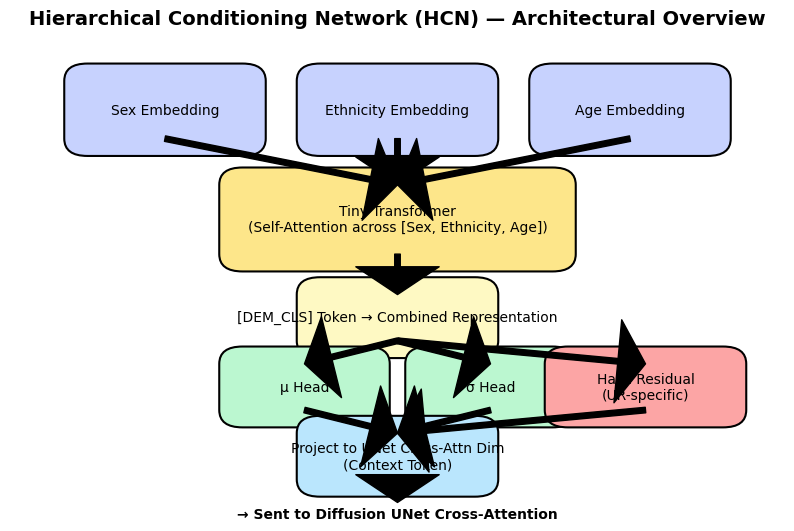

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, ArrowStyle, ConnectionPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Helper function
def add_box(x, y, w, h, text, color='#e0e7ff', fontsize=10, style='round,pad=0.3'):
    box = FancyBboxPatch((x, y), w, h, boxstyle=style, fc=color, ec='black', lw=1.5)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, wrap=True)

# Attribute embeddings
add_box(1, 6.5, 2, 1, 'Sex Embedding', '#c7d2fe')
add_box(4, 6.5, 2, 1, 'Ethnicity Embedding', '#c7d2fe')
add_box(7, 6.5, 2, 1, 'Age Embedding', '#c7d2fe')

# Transformer block
add_box(3, 4.5, 4, 1.2, 'Tiny Transformer\n(Self-Attention across [Sex, Ethnicity, Age])', '#fde68a')

# CLS Token output
add_box(4, 3, 2, 0.8, '[DEM_CLS] Token → Combined Representation', '#fef9c3')

# Uncertainty & residual heads
add_box(3, 1.8, 1.6, 0.8, 'μ Head', '#bbf7d0')
add_box(5.4, 1.8, 1.6, 0.8, 'σ Head', '#bbf7d0')
add_box(7.2, 1.8, 2, 0.8, 'Hash Residual\n(UR-specific)', '#fca5a5')

# Projection
add_box(4, 0.6, 2, 0.8, 'Project to UNet Cross-Attn Dim\n(Context Token)', '#bae6fd')

# Arrows
arrow_style = ArrowStyle("Simple,tail_width=0.4,head_width=6,head_length=2")

# From embeddings to transformer
for x in [2, 5, 8]:
    con = ConnectionPatch((x, 6.5), (5, 5.7), 'data', 'data', arrowstyle=arrow_style, color='black')
    ax.add_patch(con)

# Transformer to CLS
ax.add_patch(ConnectionPatch((5, 4.5), (5, 3.8), 'data', 'data', arrowstyle=arrow_style, color='black'))

# CLS to heads
ax.add_patch(ConnectionPatch((5, 3), (3.8, 2.6), 'data', 'data', arrowstyle=arrow_style, color='black'))
ax.add_patch(ConnectionPatch((5, 3), (6.2, 2.6), 'data', 'data', arrowstyle=arrow_style, color='black'))
ax.add_patch(ConnectionPatch((5, 3), (8.2, 2.6), 'data', 'data', arrowstyle=arrow_style, color='black'))

# Heads to projection
for x in [3.8, 6.2, 8.2]:
    ax.add_patch(ConnectionPatch((x, 1.8), (5, 1.4), 'data', 'data', arrowstyle=arrow_style, color='black'))

# Projection to output
ax.add_patch(ConnectionPatch((5, 0.6), (5, 0.2), 'data', 'data', arrowstyle=arrow_style, color='black'))

ax.text(5, 0, '→ Sent to Diffusion UNet Cross-Attention', ha='center', va='center', fontsize=10, fontweight='bold')
plt.title('Hierarchical Conditioning Network (HCN) — Architectural Overview', fontsize=14, fontweight='bold', pad=20)
plt.show()


In [ ]:
import tarfile

demo_tar_path = "/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/my_work/raw_data/mimiccxr_pa_sentence_webdataset.tar"

with tarfile.open(demo_tar_path, "r") as tar:
    print("Contents of", demo_tar_path)
    for member in tar.getmembers():
        print(member.name)


In [1]:
pkl_file = '/home/vito/ibrahimm/projects/AI4Health/notebooks/ibrahimm/Generative-Models/images/Chest_XRay/RoentGen-v2/output/test_run/validation_images/step_5000/gpu_0/labels.pkl'
import pickle

with open(pkl_file, 'rb') as f:
    labels = pickle.load(f)

print(labels)


{'disease': [tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1.,  0., -1., -1.]), tensor([-1., -1., -1.,  0., -1., -1., -1., -1., -1.,  0., -1.,  0., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1.,  1.]), tensor([-1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.]), tensor([ 1., -1., -1.,  0.,  1., -1.,  1.,  1., -1.,  1., -1., -1.,  0., -1.]), tensor([-1.,  1., -1., -1.,  0., -1., -1., -1., -1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1., -1., -1., -1., -1.,  1., -1., -1., -1., -1., -1.]), tensor([-1., -1., -1., -1.,

In [3]:
labels.keys()

dict_keys(['disease', 'sex', 'race', 'age', 'prompts'])